<a href="https://colab.research.google.com/github/krishnanjaliiyersr-lang/ICT-CASE-STUDY/blob/main/05_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("="*70)
print("ANOMALY DETECTION (ISOLATION FOREST)")
print("="*70)



ANOMALY DETECTION (ISOLATION FOREST)


In [ ]:
# =====================================================
# STEP 1: LOAD DATA
# =====================================================

print("\n📂 Loading transaction data...")

df = pd.read_csv("transaction_features.csv")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

print(f"✅ Loaded {len(df):,} transactions")
print(f"   Date range: {df['Transaction Date'].min().date()} to {df['Transaction Date'].max().date()}")
print(f"   Columns: {df.shape[1]}")




📂 Loading transaction data...
✅ Loaded 6,567 transactions
   Date range: 2015-01-09 to 2022-12-07
   Columns: 31


In [ ]:
# =====================================================
# STEP 2: PREPARE FEATURES FOR ANOMALY DETECTION
# =====================================================

print("\n" + "="*70)
print("STEP 2: PREPARING FEATURES")
print("="*70)

# Select features that indicate unusual behavior
# These are the most powerful features for finding anomalies
feature_cols = [
    "Transaction_Amount",
    "Amount_vs_User_Avg",
    "Amount_vs_User_Std",
    "Amount_vs_Category_Avg"]

# Handle any missing values
X = df[feature_cols].fillna(0)

print(f"✅ Features prepared:")
for col in feature_cols:
    print(f"   - {col}")

print(f"\n   Shape: {X.shape}")
print(f"   No missing values: {X.isnull().sum().sum() == 0}")




STEP 2: PREPARING FEATURES
✅ Features prepared:
   - Transaction_Amount
   - Amount_vs_User_Avg
   - Amount_vs_User_Std
   - Amount_vs_Category_Avg

   Shape: (6567, 4)
   No missing values: True


In [ ]:
# =====================================================
# STEP 3: SCALE FEATURES (Important for Isolation Forest)
# =====================================================

print("\n" + "="*70)
print("STEP 3: SCALING FEATURES")
print("="*70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled to standard normal distribution")
print(f"   Mean: {X_scaled.mean():.4f}")
print(f"   Std: {X_scaled.std():.4f}")


STEP 3: SCALING FEATURES
✅ Features scaled to standard normal distribution
   Mean: -0.0000
   Std: 1.0000


In [ ]:

# =====================================================
# STEP 4: TRAIN ISOLATION FOREST
# =====================================================

print("\n" + "="*70)
print("STEP 4: TRAINING ISOLATION FOREST")
print("="*70)

# contamination = expected proportion of anomalies (2-5% is typical for transactions)
model = IsolationForest(
    contamination=0.05,           # Expect ~5% anomalies (reasonable for spending)
    random_state=42,              # Reproducible results
    n_estimators=100,             # Number of trees
    max_samples='auto',
    bootstrap=False
)

# Fit the model
df["Anomaly_Score"] = model.fit_predict(X_scaled)
df["Is_Anomaly"] = (df["Anomaly_Score"] == -1).astype(int)

# Get anomaly confidence scores (lower = more anomalous)
df["Anomaly_Confidence"] = model.score_samples(X_scaled)

# Convert to 0-100 scale for easier interpretation
df["Anomaly_Confidence_Score"] = (df["Anomaly_Confidence"] - df["Anomaly_Confidence"].min()) / \
                                  (df["Anomaly_Confidence"].max() - df["Anomaly_Confidence"].min()) * 100

anomaly_count = df["Is_Anomaly"].sum()
anomaly_pct = anomaly_count / len(df) * 100

print(f"✅ Model trained successfully")
print(f"\n📊 Results:")
print(f"   Total transactions: {len(df):,}")
print(f"   Anomalies detected: {anomaly_count:,} ({anomaly_pct:.1f}%)")
print(f"   Normal transactions: {len(df) - anomaly_count:,}")



STEP 4: TRAINING ISOLATION FOREST
✅ Model trained successfully

📊 Results:
   Total transactions: 6,567
   Anomalies detected: 320 (4.9%)
   Normal transactions: 6,247


In [ ]:
# =====================================================
# STEP 5: IDENTIFY TOP ANOMALIES
# =====================================================

print("\n" + "="*70)
print("STEP 5: TOP ANOMALIES")
print("="*70)

# Sort by confidence (most anomalous first)
df_sorted = df.sort_values("Anomaly_Confidence").reset_index(drop=True)
top_anomalies = df_sorted.head(20)

print("\n🔴 TOP 10 MOST UNUSUAL TRANSACTIONS:")
print("-" * 100)
print(f"{'Date':<12} {'Amount':<12} {'Description':<35} {'Category':<15} {'Confidence':<10}")
print("-" * 100)

for _, row in top_anomalies.head(10).iterrows():
    date_str = row['Transaction Date'].strftime('%Y-%m-%d')
    amount_str = f"£{row['Transaction_Amount']:>10,.2f}"
    desc_str = row['Transaction Description'][:32]
    cat_str = row['Main_Category'][:14]
    conf_str = f"{row['Anomaly_Confidence_Score']:.1f}"
    print(f"{date_str}  {amount_str}  {desc_str:<32} {cat_str:<14} {conf_str}")



STEP 5: TOP ANOMALIES

🔴 TOP 10 MOST UNUSUAL TRANSACTIONS:
----------------------------------------------------------------------------------------------------
Date         Amount       Description                         Category        Confidence
----------------------------------------------------------------------------------------------------
2020-06-03  £ 84,000.00  R LAWRENCE                       Other          0.0
2020-03-03  £ 83,840.54  F/FLOW HOWELLS LEG               Income         0.0
2020-06-29  £  9,996.45  UNIV OF NOTTINGHAM               Income         2.6
2020-01-07  £  6,000.00  Trading212UK                     Investment     2.8
2017-06-29  £  5,619.03  DEZREZ LEGAL LTD                 Housing        3.0
2019-05-28  £  5,000.00  R LAWRENCE 25MAY19               Income         3.9
2020-02-03  £  5,000.00  R LAWRENCE 01MAR20               Income         3.9
2020-02-03  £  5,000.00  R LAWRENCE 29FEB20               Income         3.9
2020-02-03  £  5,000.00  WWW.III.

In [ ]:
# =====================================================
# STEP 6: ANOMALIES BY CATEGORY
# =====================================================

print("\n" + "="*70)
print("STEP 6: ANOMALIES BY CATEGORY")
print("="*70)

anomaly_by_category = df[df["Is_Anomaly"] == 1].groupby("Main_Category").size().sort_values(ascending=False)

print("\n📊 Anomaly Count by Category:")
print("-" * 50)
for cat, count in anomaly_by_category.head(10).items():
    total_in_cat = len(df[df["Main_Category"] == cat])
    pct = count / total_in_cat * 100 if total_in_cat > 0 else 0
    print(f"   {cat:<20} {count:>4} anomalies ({pct:.1f}% of category)")



STEP 6: ANOMALIES BY CATEGORY

📊 Anomaly Count by Category:
--------------------------------------------------
   Income                158 anomalies (35.6% of category)
   Investment             59 anomalies (39.1% of category)
   Housing                29 anomalies (49.2% of category)
   Services               26 anomalies (9.8% of category)
   Utilities              22 anomalies (3.6% of category)
   Travel                 15 anomalies (4.8% of category)
   Other                   8 anomalies (2.0% of category)
   Cash                    2 anomalies (0.4% of category)
   Food                    1 anomalies (0.1% of category)


In [ ]:

# =====================================================
# STEP 7: ANOMALY RISK SCORE (For Health Score Integration)
# =====================================================

print("\n" + "="*70)
print("STEP 7: ANOMALY RISK SCORE")
print("="*70)

# Calculate risk score based on recent anomalies (last 3 months)
recent_months = 3
latest_date = df["Transaction Date"].max()
cutoff_date = latest_date - pd.DateOffset(months=recent_months)

recent_anomalies = df[(df["Transaction Date"] >= cutoff_date) & (df["Is_Anomaly"] == 1)]
recent_total = df[df["Transaction Date"] >= cutoff_date]

recent_anomaly_rate = len(recent_anomalies) / len(recent_total) * 100 if len(recent_total) > 0 else 0

# Convert to 0-100 score (lower anomaly rate = higher score)
if recent_anomaly_rate <= 2:
    anomaly_risk_score = 100
elif recent_anomaly_rate <= 5:
    anomaly_risk_score = 80
elif recent_anomaly_rate <= 10:
    anomaly_risk_score = 60
elif recent_anomaly_rate <= 20:
    anomaly_risk_score = 40
else:
    anomaly_risk_score = 20

print(f"\n📊 Recent Anomaly Analysis (last {recent_months} months):")
print(f"   Total transactions: {len(recent_total):,}")
print(f"   Anomalies detected: {len(recent_anomalies):,}")
print(f"   Anomaly rate: {recent_anomaly_rate:.1f}%")
print(f"   Anomaly Risk Score: {anomaly_risk_score}/100")

if recent_anomaly_rate <= 2:
    print("   ✅ Low risk - Spending is normal")
elif recent_anomaly_rate <= 5:
    print("   ✅ Moderate risk - Some unusual activity")
elif recent_anomaly_rate <= 10:
    print("   ⚠️ Elevated risk - Review recent transactions")
else:
    print("   🔴 High risk - Significant unusual activity detected")


STEP 7: ANOMALY RISK SCORE

📊 Recent Anomaly Analysis (last 3 months):
   Total transactions: 59
   Anomalies detected: 0
   Anomaly rate: 0.0%
   Anomaly Risk Score: 100/100
   ✅ Low risk - Spending is normal



STEP 8: VISUALIZING ANOMALIES


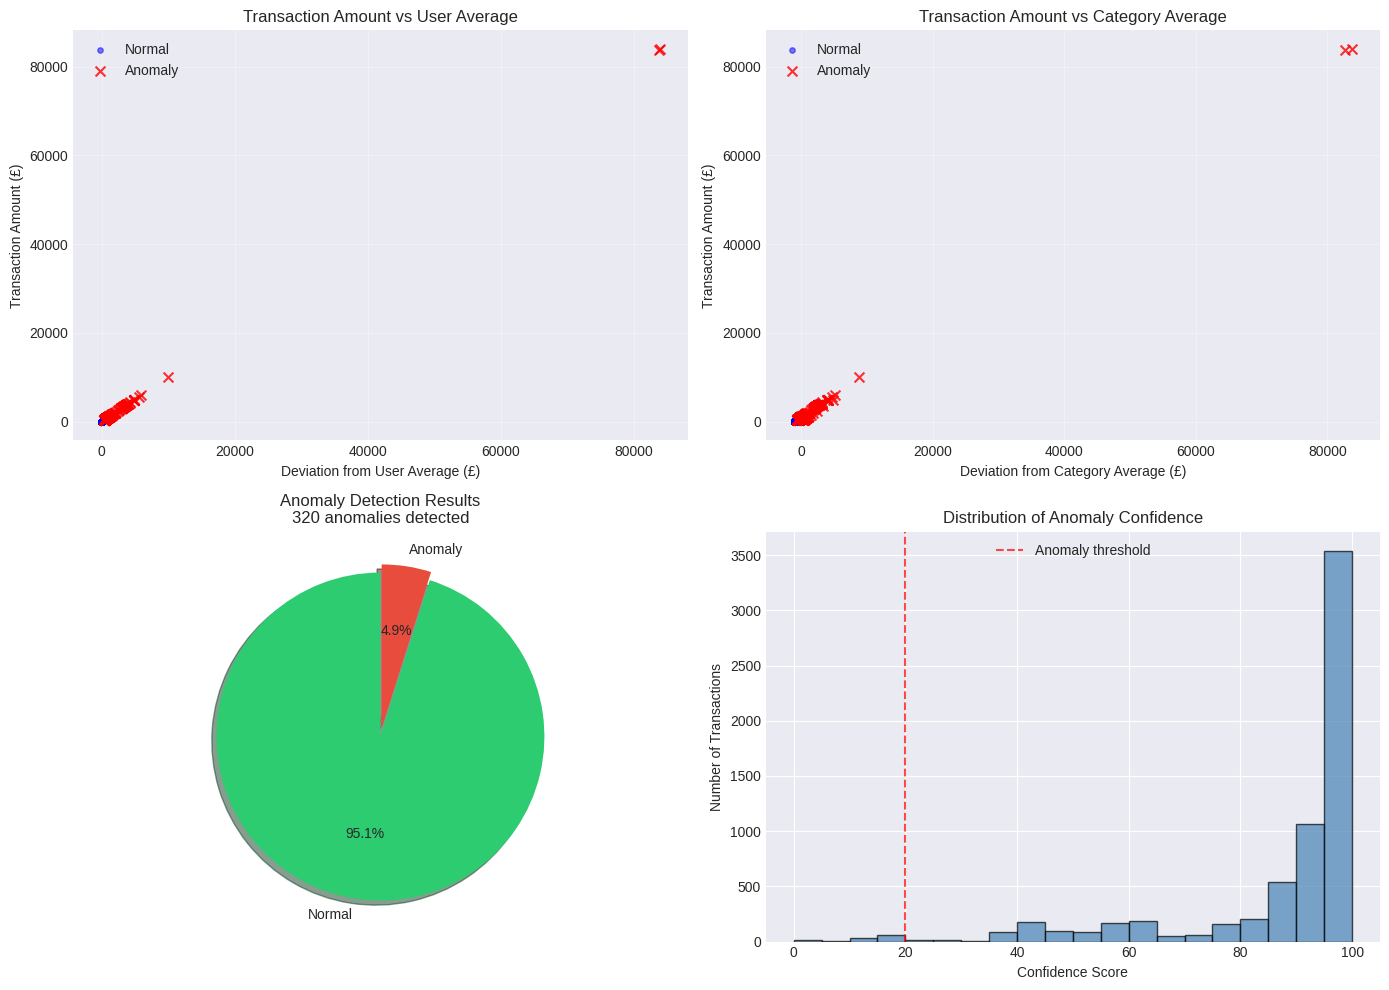

✅ Visualization saved: anomaly_detection.png


In [ ]:

# =====================================================
# STEP 8: VISUALIZE ANOMALIES
# =====================================================

print("\n" + "="*70)
print("STEP 8: VISUALIZING ANOMALIES")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot: Amount vs User Avg
normal = df[df["Is_Anomaly"] == 0]
anomaly = df[df["Is_Anomaly"] == 1]

axes[0, 0].scatter(normal["Amount_vs_User_Avg"], normal["Transaction_Amount"],
                   alpha=0.5, s=15, label="Normal", color="blue")
axes[0, 0].scatter(anomaly["Amount_vs_User_Avg"], anomaly["Transaction_Amount"],
                   alpha=0.8, s=50, label="Anomaly", color="red", marker="x")
axes[0, 0].set_xlabel("Deviation from User Average (£)")
axes[0, 0].set_ylabel("Transaction Amount (£)")
axes[0, 0].set_title("Transaction Amount vs User Average")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter plot: Amount vs Category Avg
axes[0, 1].scatter(normal["Amount_vs_Category_Avg"], normal["Transaction_Amount"],
                   alpha=0.5, s=15, label="Normal", color="blue")
axes[0, 1].scatter(anomaly["Amount_vs_Category_Avg"], anomaly["Transaction_Amount"],
                   alpha=0.8, s=50, label="Anomaly", color="red", marker="x")
axes[0, 1].set_xlabel("Deviation from Category Average (£)")
axes[0, 1].set_ylabel("Transaction Amount (£)")
axes[0, 1].set_title("Transaction Amount vs Category Average")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Pie chart: Anomaly vs Normal
labels = ['Normal', 'Anomaly']
sizes = [len(df) - anomaly_count, anomaly_count]
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.05)

axes[1, 0].pie(sizes, explode=explode, labels=labels, colors=colors,
               autopct='%1.1f%%', shadow=True, startangle=90)
axes[1, 0].set_title(f'Anomaly Detection Results\n{anomaly_count:,} anomalies detected')

# 4. Anomaly confidence distribution
axes[1, 1].hist(df["Anomaly_Confidence_Score"], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Anomaly threshold')
axes[1, 1].set_xlabel("Confidence Score")
axes[1, 1].set_ylabel("Number of Transactions")
axes[1, 1].set_title("Distribution of Anomaly Confidence")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: anomaly_detection.png")

In [ ]:
# =====================================================
# STEP 9: ANOMALY SUMMARY REPORT
# =====================================================

print("\n" + "="*70)
print("STEP 9: ANOMALY SUMMARY REPORT")
print("="*70)

# Count anomalies by type (based on category)
anomaly_by_type = df[df["Is_Anomaly"] == 1].groupby("Main_Category").size().sort_values(ascending=False)

total_anomaly_value = df[df["Is_Anomaly"] == 1]["Transaction_Amount"].sum()
total_normal_value = df[df["Is_Anomaly"] == 0]["Transaction_Amount"].sum()
total_spend = total_anomaly_value + total_normal_value

print(f"\n📊 Anomaly Impact Summary:")
print(f"   Total spending: £{total_spend:,.2f}")
print(f"   Anomaly spending: £{total_anomaly_value:,.2f} ({total_anomaly_value/total_spend*100:.1f}%)")
print(f"   Normal spending: £{total_normal_value:,.2f} ({total_normal_value/total_spend*100:.1f}%)")

print(f"\n📊 Top Anomaly Categories:")
for cat, count in anomaly_by_type.head(5).items():
    total_in_cat = len(df[df["Main_Category"] == cat])
    pct = count / total_in_cat * 100 if total_in_cat > 0 else 0
    cat_spend = df[(df["Main_Category"] == cat) & (df["Is_Anomaly"] == 1)]["Transaction_Amount"].sum()
    print(f"   {cat}: {count} anomalies ({pct:.1f}% of category) - £{cat_spend:,.2f}")



STEP 9: ANOMALY SUMMARY REPORT

📊 Anomaly Impact Summary:
   Total spending: £1,014,382.21
   Anomaly spending: £745,334.54 (73.5%)
   Normal spending: £269,047.67 (26.5%)

📊 Top Anomaly Categories:
   Income: 158 anomalies (35.6% of category) - £471,477.13
   Investment: 59 anomalies (39.1% of category) - £89,960.75
   Housing: 29 anomalies (49.2% of category) - £29,552.63
   Services: 26 anomalies (9.8% of category) - £31,001.32
   Utilities: 22 anomalies (3.6% of category) - £20,819.17


In [ ]:

# =====================================================
# STEP 10: SAVE RESULTS
# =====================================================

print("\n" + "="*70)
print("STEP 10: SAVING RESULTS")
print("="*70)

# Save full dataset with anomaly labels
df.to_csv("transactions_with_anomalies.csv", index=False)
print("✅ Saved: transactions_with_anomalies.csv")

# Save only anomalies for review
anomalies_only = df[df["Is_Anomaly"] == 1].sort_values("Anomaly_Confidence")
anomalies_only.to_csv("anomalies_list.csv", index=False)
print("✅ Saved: anomalies_list.csv")

# Save anomaly summary for health score integration
anomaly_summary = pd.DataFrame({
    'Metric': ['Total Transactions', 'Anomalies Detected', 'Anomaly Rate (%)',
               'Recent Anomaly Rate (%)', 'Anomaly Risk Score', 'Anomaly Spend (%)'],
    'Value': [len(df), anomaly_count, f"{anomaly_pct:.1f}%",
              f"{recent_anomaly_rate:.1f}%", f"{anomaly_risk_score}/100",
              f"{total_anomaly_value/total_spend*100:.1f}%"]
})
anomaly_summary.to_csv("anomaly_summary.csv", index=False)
print("✅ Saved: anomaly_summary.csv")




STEP 10: SAVING RESULTS
✅ Saved: transactions_with_anomalies.csv
✅ Saved: anomalies_list.csv
✅ Saved: anomaly_summary.csv
